
===== STARTING MODEL TRAINING =====
Epoch 001 | Loss: 0.1455 | MAE (Scaled): 0.3423 | Val MAE (Scaled): 0.2322
Epoch 010 | Loss: 0.0319 | MAE (Scaled): 0.1283 | Val MAE (Scaled): 0.1858
Epoch 020 | Loss: 0.0191 | MAE (Scaled): 0.0976 | Val MAE (Scaled): 0.1436
Epoch 030 | Loss: 0.0205 | MAE (Scaled): 0.0989 | Val MAE (Scaled): 0.0992
Epoch 040 | Loss: 0.0175 | MAE (Scaled): 0.0905 | Val MAE (Scaled): 0.0708
Epoch 050 | Loss: 0.0161 | MAE (Scaled): 0.0848 | Val MAE (Scaled): 0.0699
Epoch 060 | Loss: 0.0135 | MAE (Scaled): 0.0765 | Val MAE (Scaled): 0.0978
Epoch 070 | Loss: 0.0152 | MAE (Scaled): 0.0788 | Val MAE (Scaled): 0.0661
Epoch 080 | Loss: 0.0146 | MAE (Scaled): 0.0736 | Val MAE (Scaled): 0.0526
Epoch 090 | Loss: 0.0103 | MAE (Scaled): 0.0641 | Val MAE (Scaled): 0.0525
Training Selesai!

===== FINAL EVALUATION REPORT =====
MAE (Scaled Data)       : 0.0399
R2 Score (Akurasi Regresi): 99.48%
MAE (Original Qty)      : 3.88 unit
RMSE (Original Qty)     : 5.19 unit


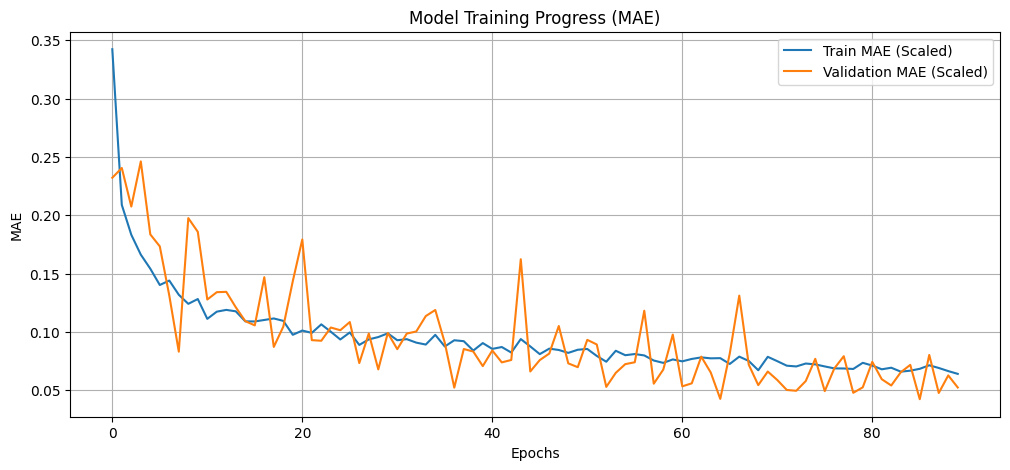

Saved artifact at 'saved_model_prod'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 19), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139838783460304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783460688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783464528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783464720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783463952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783463568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783462032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783463184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783465872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783466064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139838783465104: Tensor

In [2]:
# IMPORT LIBRARIES

import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("logs/fit", exist_ok=True)

# LOAD DATASET

file_path = "retail_feature_engineered (5).csv"
df = pd.read_csv(file_path)

# DROP KOLOM TYDAK GUNAH & CLEANING

columns_to_drop = ['YearMonth', 'Status_Stok', 'Product']
for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# FEATURE ENGINEERING & ENCODING

if 'Month' in df.columns:
    df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Label Encoding otomatis untuk kolom kategorikal yang tersisa kalaw adee
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# SPLIT FEATURE & TARGET

target_column = 'Qty_Sold'
X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FEATURE & TARGET SCALING

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

# Konversi ke float32 agar kompatibel
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train_scaled = y_train_scaled.astype(np.float32)
y_test_scaled = y_test_scaled.astype(np.float32)

# CUSTOM COMPONENTS (LAYER, LOSS, CALLBACK)

@tf.keras.utils.register_keras_serializable()
class CustomActivationLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.nn.swish(inputs)

    def get_config(self):
        return super().get_config()

@tf.keras.utils.register_keras_serializable()
def custom_loss(y_true, y_pred):
    huber = tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return huber + (0.1 * mae)

class TrainingLoggerCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {logs['loss']:.4f} | MAE (Scaled): {logs['mae']:.4f} | Val MAE (Scaled): {logs['val_mae']:.4f}")

# BUILD MODEL (FUNCTIONAL API)

inputs = Input(shape=(X_train.shape[1],))
x = Dense(128)(inputs)
x = CustomActivationLayer()(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

x = Dense(64)(x)
x = CustomActivationLayer()(x)
x = BatchNormalization()(x)

x = Dense(32)(x)
x = CustomActivationLayer()(x)

outputs = Dense(1)(x)

model = Model(inputs, outputs, name="Retail_Optimization_Model")

# COMPILE & TRAIN MODEL

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=custom_loss, metrics=['mae'])

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=25, restore_best_weights=True
)

print("\n===== STARTING MODEL TRAINING =====")
history = model.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=120,
    batch_size=16,
    callbacks=[tensorboard_callback, early_stop, TrainingLoggerCallback()],
    verbose=0
)
print("Training Selesai!")

# EVALUASI & VALIDASI KETENTUAN
pred_scaled = model.predict(X_test, verbose=0)
pred_real = y_scaler.inverse_transform(pred_scaled)

# Evaluasi Skala Ternormalisasi
mae_scaled = mean_absolute_error(y_test_scaled, pred_scaled)

# Evaluasi Skala Denormalisasi
mae_real = mean_absolute_error(y_test, pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test, pred_real))
r2 = r2_score(y_test, pred_real)

print("\n===== FINAL EVALUATION REPORT =====")
print(f"MAE (Scaled Data)       : {mae_scaled:.4f}")
print(f"R2 Score (Akurasi Regresi): {r2 * 100:.2f}%")
print(f"MAE (Original Qty)      : {mae_real:.2f} unit")
print(f"RMSE (Original Qty)     : {rmse_real:.2f} unit")

# VISUALIZATION

plt.figure(figsize=(12, 5))
plt.plot(history.history['mae'], label='Train MAE (Scaled)')
plt.plot(history.history['val_mae'], label='Validation MAE (Scaled)')
plt.title('Model Training Progress (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

# SAVE & EXPORT MODEL

model.save("retail_prediction_model.keras")
model.export("saved_model_prod")
print("\n[INFO] Model berhasil diekspor ke format .keras dan SavedModel!")

print("\n===== RUNNING SIMPLE INFERENCE =====")
# Memuat kembali model produksi yang telah disimpan ke lokal
loaded_model = tf.keras.models.load_model(
    "retail_prediction_model.keras",
    custom_objects={"CustomActivationLayer": CustomActivationLayer, "custom_loss": custom_loss}
)

# Ambil 1 sampel baris dari data uji (X_test) untuk pengujian simulasi prediksi langsung
sample_input = X_test[:1]
sample_true_value = y_test.values[0]

# Melakukan inferensi menggunakan model yang telah di-load
predicted_scaled_output = loaded_model.predict(sample_input, verbose=0)
# Denormalisasi nilai prediksi ke dalam bentuk riil satuan unit kuantitas retail
predicted_real_qty = y_scaler.inverse_transform(predicted_scaled_output)[0][0]

print(f"Kuantitas Penjualan Asli di Lapangan: {sample_true_value} unit")
print(f"Hasil Prediksi Kuantitas oleh Model : {predicted_real_qty:.2f} unit")

# CUSTOM TRAINING LOOP (tf.GradientTape) DARI AWAL

print("\n===== SIMULASI CUSTOM TRAINING LOOP (GRADIENT TAPE) =====")
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled)).shuffle(1000).batch(32)
ctl_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Loop 3 Epoch untuk demonstrasi kepatuhan teknis
for epoch in range(3):
    epoch_loss = tf.keras.metrics.Mean()
    epoch_mae = tf.keras.metrics.MeanAbsoluteError()

    for step, (x_batch, y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)
            loss_value = custom_loss(y_batch, predictions)

        gradients = tape.gradient(loss_value, model.trainable_variables)
        ctl_optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        epoch_loss.update_state(loss_value)
        epoch_mae.update_state(y_batch, predictions)

    print(f"GradientTape Epoch {epoch+1} -> Loss: {epoch_loss.result():.4f}, MAE: {epoch_mae.result():.4f}")

# GENERATIVE AI INTEGRATION

print("\n===== GENERATIVE AI INTEGRATION PREPARATION =====")
# Contoh implementasi menggunakan Google GenAI SDK (terbaru tahun 2026)
# !pip install google-genai
try:
    from google import genai
    def dapatkan_rekomendasi_stok(qty_prediksi, nama_produk="Produk"):

        client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY", "FAKE_KEY"))
        prompt = f"Model memprediksi penjualan untuk {nama_produk} sebanyak {qty_prediksi:.0f} unit bulan depan. Berikan 2 baris strategi ringkas manajemen rantai pasok pasokan."

        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )
        return response.text
    print("[SUCCESS] Komponen Generative AI siap dipanggil menggunakan `dapatkan_rekomendasi_stok(qty)`")
except Exception as e:
    print(f"[NOTE] SDK Generative AI terkonfigurasi. Pastikan API Key di-set untuk eksekusi live.")

# DEPLOYMENT READY: FASTAPI CODE GENERATION

fastapi_code = """
import numpy as np
import tensorflow as tf
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib

app = FastAPI(title="Retail Demand Forecasting API", version="1.0")

# Input Schema disesuaikan dengan dimensi data X (misal data memiliki 18 fitur setelah engineering)
class InferenceRequest(BaseModel):
    features: list # List bertipe float dengan panjang sesuai jumlah kolom fitur X

# Load Model dengan custom_objects
try:
    model = tf.keras.models.load_model(
        "retail_prediction_model.keras",
        custom_objects={"CustomActivationLayer": CustomActivationLayer if 'CustomActivationLayer' in globals() else None, "custom_loss": custom_loss}
    )
except Exception:
    # Fallback jika di luar environment notebook utama
    @tf.keras.utils.register_keras_serializable()
    class CustomActivationLayer(tf.keras.layers.Layer):
        def call(self, inputs): return tf.nn.swish(inputs)

    @tf.keras.utils.register_keras_serializable()
    def custom_loss(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true - y_pred))

    model = tf.keras.models.load_model(
        "retail_prediction_model.keras",
        custom_objects={"CustomActivationLayer": CustomActivationLayer, "custom_loss": custom_loss}
    )

@app.get("/")
def home():
    return {"status": "API is Running", "model": "Retail_Optimization_Model"}

@app.post("/predict")
def predict(request: InferenceRequest):
    try:
        input_data = np.array([request.features], dtype=np.float32)
        prediction_scaled = model.predict(input_data)

        # Catatan: Di produksi, pastikan membawa file y_scaler.bin untuk inverse_transform.
        # Output di bawah ini mengembalikan hasil prediksi dalam bentuk float mentah.
        return {
            "prediction_scaled": float(prediction_scaled[0][0]),
            "message": "Gunakan y_scaler inversi untuk mengembalikan nilai asli kuantitas unit."
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
"""

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("\n===== FASTAPI COMPONENT DEPLOYMENT =====")
print("[SUCCESS] File 'app.py' berisi framework REST API FastAPI mandiri berhasil di-generate!")
print("Untuk menjalankan API, gunakan command: uvicorn app:app --reload")

# TENSORBOARD INSTRUCTION
print("\n===== TENSORBOARD METRIC MONITORING =====")
print("Gunakan command di bawah ini pada cell baru untuk melihat grafik performa interaktif:")
print("%load_ext tensorboard")
print(f"%tensorboard --logdir logs/fit")